In [1]:
# ============================================================
# WOCHE 2 — STATISTISCHE MODELLE
# ARIMA, SARIMA, Exponentielle Glättung
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # ARIMA gibt viele Warnungen

# Farb-Fix Windows 125% Skalierung
matplotlib.rcParams['text.color']       = 'black'
matplotlib.rcParams['axes.labelcolor']  = 'black'
matplotlib.rcParams['xtick.color']      = 'black'
matplotlib.rcParams['ytick.color']      = 'black'
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor']   = 'white'
matplotlib.rcParams['font.family']      = 'DejaVu Sans'

# --- Pfade ---
DATA_RAW  = "../data/raw/"
DATA_PROC = "../data/processed/"
DATA_PLOT = "../data/plots/"

# --- Daten laden ---
df = pd.read_csv(DATA_PROC + "timeseries_cleaned.csv",
                 index_col='date', parse_dates=True)

# --- Train/Test Split ---
# Training: 01.01.2013 – 31.12.2013
# Test:     01.01.2014 – 31.03.2014
train = df.loc['2013-01-01':'2013-12-31', 'unit_sales']
test  = df.loc['2014-01-01':'2014-03-31', 'unit_sales']

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Training: {train.index.min().date()} → {train.index.max().date()}")
print(f"          {len(train)} Tage")
print(f"Test:     {test.index.min().date()} → {test.index.max().date()}")
print(f"          {len(test)} Tage")
print(f"\nTraining Mittelwert: {train.mean():.1f}")
print(f"Test Mittelwert:     {test.mean():.1f}")

TRAIN / TEST SPLIT
Training: 2013-01-02 → 2013-12-31
          364 Tage
Test:     2014-01-01 → 2014-03-31
          90 Tage

Training Mittelwert: 477.4
Test Mittelwert:     480.4


## Schritt 1: Train/Test Split

### Ergebnis

| Datensatz | Zeitraum | Tage | Mittelwert |
|---|---|---|---|
| Training | 02.01.2013 – 31.12.2013 | 364 | 477.4 Einheiten |
| Test | 01.01.2014 – 31.03.2014 | 90 | 480.4 Einheiten |

### Analyse

Der Mittelwert von Training (477.4) und Test (480.4) sind nahezu
identisch (+0.6%) — ein Indikator für einen stabilen, trendlosen
Datensatz. Der Split ist sachlich korrekt: das Modell wird
ausschließlich auf Vergangenheitsdaten trainiert und auf einem
separaten, zeitlich späteren Zeitraum evaluiert.

### Wichtiger Hinweis zu Zeitreihen-Splits

Bei Zeitreihen darf **kein zufälliger Split** verwendet werden
(wie bei klassischen ML-Problemen). Die zeitliche Reihenfolge
muss zwingend erhalten bleiben — sonst würde das Modell
"in die Zukunft schauen" (Data Leakage).

```
Klassisches ML:  [──●──●──●──●──●──●──●──●──]  → zufälliger Split ✅
Zeitreihen:      [────── TRAIN ──────][─TEST─]  → chronologischer Split ✅
```

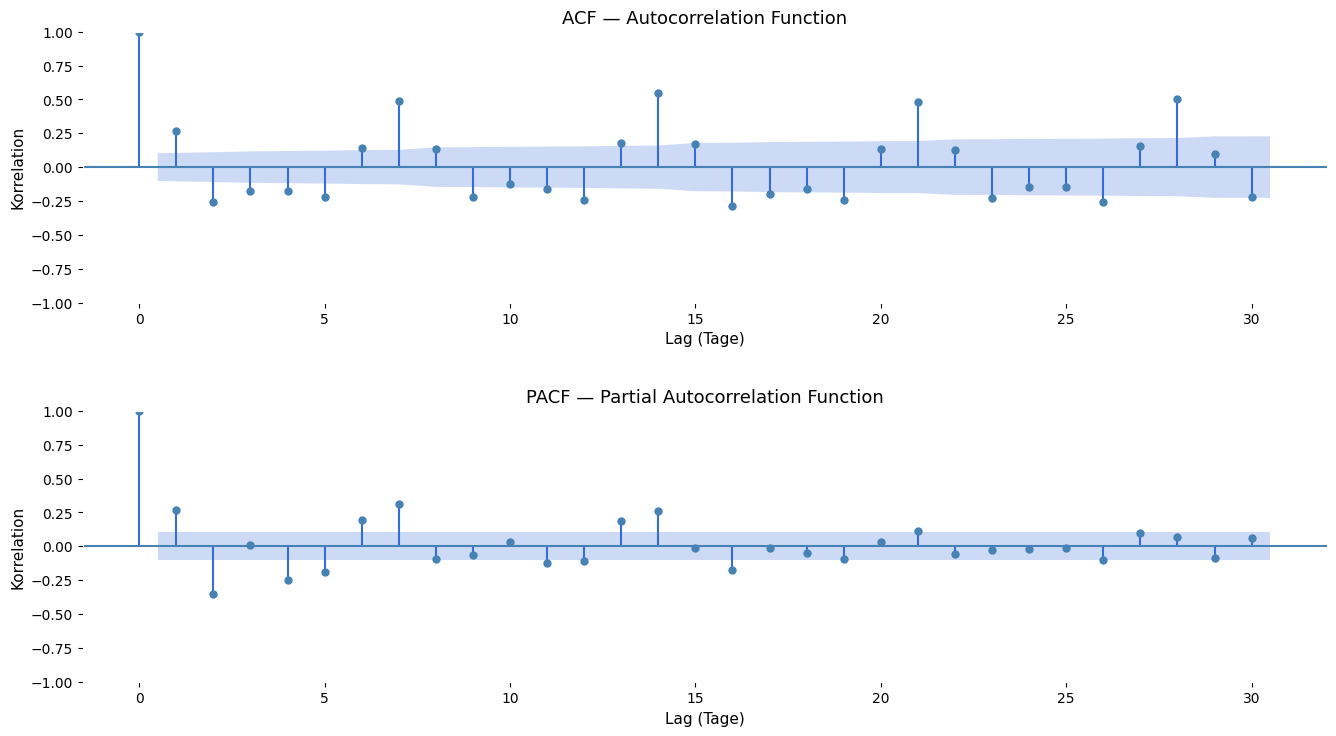


Signifikanzschwelle: ±0.1027

 Lag        ACF   Signifikant       PACF   Signifikant
-------------------------------------------------------
   1     0.2658          ✅ JA     0.2658          ✅ JA
   2    -0.2579          ✅ JA    -0.3535          ✅ JA
   3    -0.1781          ✅ JA     0.0107          nein
   4    -0.1737          ✅ JA    -0.2508          ✅ JA
   5    -0.2210          ✅ JA    -0.1890          ✅ JA
   6     0.1384          ✅ JA     0.1919          ✅ JA
   7     0.4894          ✅ JA     0.3147          ✅ JA
   8     0.1354          ✅ JA    -0.0924          nein
   9    -0.2187          ✅ JA    -0.0657          nein
  10    -0.1224          ✅ JA     0.0337          nein
  11    -0.1603          ✅ JA    -0.1270          ✅ JA
  12    -0.2424          ✅ JA    -0.1110          ✅ JA
  13     0.1762          ✅ JA     0.1885          ✅ JA
  14     0.5470          ✅ JA     0.2641          ✅ JA
  15     0.1713          ✅ JA    -0.0147          nein
  16    -0.2854          ✅ JA    

In [2]:
# ============================================================
# SCHRITT 2: ACF & PACF — p und q Parameter bestimmen
# ============================================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train, lags=30, ax=axes[0], color='steelblue')
axes[0].set_title('ACF — Autocorrelation Function', fontsize=13)
axes[0].set_xlabel('Lag (Tage)', fontsize=11)
axes[0].set_ylabel('Korrelation', fontsize=11)

plot_pacf(train, lags=30, ax=axes[1], color='steelblue', method='ywm')
axes[1].set_title('PACF — Partial Autocorrelation Function', fontsize=13)
axes[1].set_xlabel('Lag (Tage)', fontsize=11)
axes[1].set_ylabel('Korrelation', fontsize=11)

plt.tight_layout(pad=3.0)
plt.savefig(DATA_PLOT + 'plot6_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Tabelle ACF & PACF Werte ---
acf_vals  = acf(train,  nlags=30)
pacf_vals = pacf(train, nlags=30, method='ywm')

# Signifikanzschwelle: 1.96 / sqrt(n)
schwelle = 1.96 / np.sqrt(len(train))

print(f"\nSignifikanzschwelle: ±{schwelle:.4f}")
print(f"\n{'Lag':>4} {'ACF':>10} {'Signifikant':>13} {'PACF':>10} {'Signifikant':>13}")
print("-" * 55)
for lag in range(1, 31):
    acf_sig  = "✅ JA" if abs(acf_vals[lag])  > schwelle else "nein"
    pacf_sig = "✅ JA" if abs(pacf_vals[lag]) > schwelle else "nein"
    print(f"{lag:>4} {acf_vals[lag]:>10.4f} {acf_sig:>13} "
          f"{pacf_vals[lag]:>10.4f} {pacf_sig:>13}")

## Schritt 2: ACF & PACF Analyse — Ergebnis & Analyse

### Ergebnis

Signifikanzschwelle: ±0.1027 (berechnet als 1.96 / √364)

**Signifikante Lags im Überblick:**

| Lag | ACF | PACF | Bemerkung |
|---|---|---|---|
| 1 | 0.2658 ✅ | 0.2658 ✅ | Starke direkte Autokorrelation |
| 2 | -0.2579 ✅ | -0.3535 ✅ | Negative Korrelation |
| 4 | -0.1737 ✅ | -0.2508 ✅ | Wochenmuster-Vorbote |
| 5 | -0.2210 ✅ | -0.1890 ✅ | Wochenmuster-Vorbote |
| 7 | 0.4894 ✅ | 0.3147 ✅ | **Saisonalitäts-Peak (Woche 1)** |
| 14 | 0.5470 ✅ | 0.2641 ✅ | **Saisonalitäts-Peak (Woche 2)** |
| 21 | 0.4801 ✅ | 0.1159 ✅ | **Saisonalitäts-Peak (Woche 3)** |
| 28 | 0.4999 ✅ | 0.0696 nein | **Saisonalitäts-Peak (Woche 4)** |

Von 30 getesteten Lags sind **29 ACF-Werte** und **16 PACF-Werte**
statistisch signifikant.

### Analyse

**Wochensaisonalität (s=7):**
Das dominante Muster sind die ACF-Peaks bei den Lags 7, 14, 21
und 28 mit Werten zwischen 0.48 und 0.55. Diese wiederkehrenden
positiven Spitzen im Abstand von exakt 7 Tagen bestätigen die
wöchentliche Saisonalität mathematisch — konsistent mit den
Ergebnissen aus Woche 1 (Plot 3: Wochenmuster, Zerlegung).

**PACF-Verhalten:**
Die PACF zeigt signifikante Werte bei Lag 1 (0.266) und Lag 2
(-0.354), danach kein klarer Cut-off. Dies deutet auf einen
AR-Prozess der Ordnung p=1 oder p=2 hin.

**ACF-Verhalten:**
Die ACF fällt nicht exponentiell ab sondern zeigt ein
wiederkehrendes Wellenmuster — typisch für saisonale Zeitreihen.
Ein klarer Cut-off für q ist nicht erkennbar, weshalb q=1
als konservativer Startwert gewählt wird.

### Parameter-Entscheidung für Modellierung

| Modell | Parameter | Begründung |
|---|---|---|
| ARIMA | (p=1, d=0, q=1) | Baseline — ignoriert Saisonalität |
| SARIMA | (1,0,1)(1,0,1,7) | Berücksichtigt Wochenmuster s=7 |

**Wichtiger Hinweis:**
Da die ACF-Peaks bei Lag 7, 14, 21, 28 dominieren, ist reines
ARIMA strukturell ungeeignet — es kann die Wochensaisonalität
nicht modellieren. SARIMA ist die sachlich korrekte Wahl.
ARIMA wird dennoch als Baseline trainiert um den Unterschied
quantitativ zu belegen.

### Empfehlung

1. ARIMA(1,0,1) als Baseline trainieren
2. SARIMA(1,0,1)(1,0,1,7) als verbessertes Modell trainieren
3. Beide Modelle mit identischen Metriken (MAE, MSE, RMSE)
   auf dem Testzeitraum Januar–März 2014 evaluieren
4. In Woche 3: Hyperparameter-Tuning der SARIMA-Parameter
   mit HyperOpt verfeinern

## Exkurs: ACF & PACF — Mathematischer Hintergrund

### 1. Signifikanzschwelle

**Definition:**
$$\text{Schwelle} = \frac{1.96}{\sqrt{n}} = \frac{1.96}{\sqrt{364}} = \pm 0.1027$$

Die Zahl 1.96 stammt aus der Normalverteilung und entspricht dem
95% Konfidenzintervall. Bei n=364 Beobachtungen ergibt sich
eine Schwelle von ±0.1027.

**Deutung:**
Liegt ein ACF- oder PACF-Wert **außerhalb** dieser Schwelle,
ist die Korrelation bei diesem Lag statistisch signifikant —
d.h. kein Zufall, sondern ein echtes Muster in den Daten.

**In unserem Fall:**
Lag 7 hat ACF = 0.49 → weit außerhalb ±0.1027 → hochsignifikant.
Lag 29 hat ACF = 0.10 → innerhalb ±0.1027 → nicht signifikant.

---

### 2. ACF vs. PACF — Der Unterschied

**Analogie aus dem Ingenieurwesen:**
Stell dir eine Kette von Zahnrädern vor:
Zahnrad 1 → Zahnrad 2 → Zahnrad 3

| | ACF | PACF |
|---|---|---|
| **Misst** | Gesamtkorrelation zwischen Tag t und Tag t-k | Direkte Korrelation — bereinigt um Zwischenlags |
| **Analogie** | Einfluss von Zahnrad 1 auf Zahnrad 3 (inkl. Zahnrad 2) | Direkter Einfluss von Zahnrad 1 auf Zahnrad 3 (ohne Zahnrad 2) |
| **Bestimmt** | q (Moving Average Parameter) | p (AutoRegression Parameter) |

**Konkretes Beispiel aus unseren Daten:**
ACF  Lag 7 = 0.49  → Verkauf heute korreliert mit Verkauf
vor 7 Tagen (INKL. aller Zwischentage)
PACF Lag 7 = 0.31  → Direkter Einfluss von vor 7 Tagen,
BEREINIGT um Lags 1-6

Der PACF-Wert ist kleiner weil ein Teil der Korrelation
bereits durch die Zwischentage (Lags 1-6) erklärt wird.

---

### 3. Parameter p, d, q und s

#### ARIMA(p, d, q)

**p — AutoRegression (AR)**
Anzahl vergangener Werte die zur Vorhersage verwendet werden.

$$\hat{y}_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + ... + \phi_p y_{t-p} + \epsilon_t$$

Beispiel p=2: Der heutige Verkauf wird aus den letzten
2 Tagen berechnet.
Verkauf heute = c + (φ₁ × gestern) + (φ₂ × vorgestern) + Fehler
**Wie p bestimmen?** → PACF: letzter signifikanter Lag vor Cut-off.

---

**d — Integration (Differenzierung)**
Anzahl der Differenzierungen um Stationarität herzustellen.

$$y'_t = y_t - y_{t-1}$$

| d | Bedeutung |
|---|---|
| 0 | Zeitreihe bereits stationär (unser Fall ✅) |
| 1 | Einmal differenzieren (Trend entfernen) |
| 2 | Zweimal differenzieren (starker Trend) |

---

**q — Moving Average (MA)**
Anzahl vergangener Fehler die zur Vorhersage verwendet werden.

$$\hat{y}_t = c + \epsilon_t + \theta_1\epsilon_{t-1} + ... + \theta_q\epsilon_{t-q}$$

Beispiel q=1: Der heutige Verkauf wird aus dem gestrigen
Vorhersagefehler korrigiert.
Verkauf heute = c + Fehler heute + (θ₁ × Fehler gestern)

**Wie q bestimmen?** → ACF: letzter signifikanter Lag vor Cut-off.

---

**s — Saisonalität (nur bei SARIMA)**
Länge eines vollständigen Saisonzyklus.

| s | Bedeutung |
|---|---|
| 7 | Wöchentlicher Zyklus (unser Fall) |
| 12 | Monatlicher Zyklus (bei Monatsdaten) |
| 52 | Jährlicher Zyklus (bei Wochendaten) |

SARIMA erweitert ARIMA um saisonale Versionen der Parameter:
SARIMA (p, d, q) × (P, D, Q, s)

---

### 4. Der hellblaue Bereich im Diagramm

Der hellblaue Bereich ist das **95% Konfidenzintervall** —
die visuelle Darstellung der Signifikanzschwelle ±0.1027.

Das Konfidenzband wird nach rechts leicht breiter weil bei
höheren Lags weniger Datenpunkte für die Berechnung zur
Verfügung stehen → größere statistische Unsicherheit.

---

### 5. Warum werden PACF-Werte kleiner?

Die PACF "bereinigt" jeden Lag um den Einfluss aller
dazwischenliegenden Lags. Mit steigendem Lag gibt es
mehr Zwischenstufen die herausgerechnet werden.

**Schematisch:**
Lag 1: PACF = direkter Einfluss von t-1
(keine Zwischenstufen)        → groß: 0.266
Lag 7: PACF = direkter Einfluss von t-7
(bereinigt um Lags 1,2,3,4,5,6) → kleiner: 0.315
Lag 14: PACF = direkter Einfluss von t-14
(bereinigt um Lags 1...13)   → noch kleiner: 0.264

Bei einem "reinen" AR(p)-Prozess würde die PACF nach Lag p
**abrupt auf 0 fallen** — ein sogenannter "Cut-off".
In unseren Daten gibt es keinen klaren Cut-off weil die
Wochensaisonalität mehrere Lags gleichzeitig beeinflusst.
Dies bestätigt dass SARIMA (mit saisonalem Term s=7)
geeigneter ist als reines ARIMA.


## Exkurs: AR-Prozess und Ordnung p — Erklärung

### Was bedeutet "Ordnung" bei AR?

Die Ordnung p gibt an, **wie viele vergangene Tage**
das Modell zur Vorhersage verwendet.

| Modell | Formel | Bedeutung |
|---|---|---|
| AR(1) | ŷₜ = c + φ₁·yₜ₋₁ | Nur gestern beeinflusst heute |
| AR(2) | ŷₜ = c + φ₁·yₜ₋₁ + φ₂·yₜ₋₂ | Gestern UND vorgestern beeinflussen heute |
| AR(p) | ŷₜ = c + φ₁·yₜ₋₁ + ... + φₚ·yₜ₋ₚ | Die letzten p Tage beeinflussen heute |

### Konkretes Beispiel mit unseren Daten

**AR(1) — Ordnung 1:**
Verkauf Mittwoch = 478 + (0.266 × Verkauf Dienstag)
= 478 + (0.266 × 450)
= 478 + 119.7
= 598 Einheiten

Nur der gestrige Tag wird berücksichtigt.

**AR(2) — Ordnung 2:**
Verkauf Mittwoch = 478 + (0.266 × Verkauf Dienstag)
+ (-0.354 × Verkauf Montag)
= 478 + (0.266 × 450)
+ (-0.354 × 620)
= 478 + 119.7 - 219.5
= 378 Einheiten

Gestern UND vorgestern werden berücksichtigt.

### Wie bestimmt man p aus der PACF?

Die Regel ist einfach:
**p = letzter Lag bei dem PACF signifikant ist
     bevor sie dauerhaft innerhalb der Schwelle bleibt**

**Idealer Fall — klarer Cut-off bei p=2:**
Lag 1:  PACF = 0.45  ✅ signifikant
Lag 2:  PACF = 0.31  ✅ signifikant
Lag 3:  PACF = 0.03  ── nicht signifikant  ← Cut-off hier
Lag 4:  PACF = 0.02  ── nicht signifikant
Lag 5:  PACF = 0.01  ── nicht signifikant
→ p = 2

**Unser Fall — kein klarer Cut-off:**
Lag 1:  PACF = 0.266   ✅ signifikant
Lag 2:  PACF = -0.354  ✅ signifikant
Lag 3:  PACF = 0.011   ── nicht signifikant
Lag 4:  PACF = -0.251  ✅ signifikant  ← wieder signifikant!
Lag 5:  PACF = -0.189  ✅ signifikant
Lag 6:  PACF = 0.192   ✅ signifikant
Lag 7:  PACF = 0.315   ✅ signifikant  ← Saisonalitäts-Peak

Es gibt keinen klaren Cut-off weil die Wochensaisonalität
die PACF bei Lag 4, 5, 6, 7 wieder ansteigen lässt.
Deshalb:
- p=1 oder p=2 als Startwert für den nicht-saisonalen Teil
- Der Rest (Lags 4-7) wird durch den saisonalen Term
  s=7 in SARIMA erklärt

### Fazit

| Situation | Entscheidung |
|---|---|
| Klarer Cut-off bei Lag 2 | p=2, reines ARIMA ausreichend |
| Kein klarer Cut-off | Saisonalität vorhanden → SARIMA nötig |
| Unser Fall | p=1 als Start, s=7 für Saisonalität |

Der Parameter p kontrolliert nur den
**kurzfristigen Gedächtniseffekt** (1-2 Tage).
Die **Wochensaisonalität** wird separat durch s=7
im saisonalen Term von SARIMA modelliert.

ARIMA(1,0,1) — Training


C:\_AA-LapTop-MSIT\_MyMSIT_TimeSeries_Term8\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\_AA-LapTop-MSIT\_MyMSIT_TimeSeries_Term8\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\_AA-LapTop-MSIT\_MyMSIT_TimeSeries_Term8\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             unit_sales   No. Observations:                  364
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2351.320
Date:                Sat, 18 Apr 2026   AIC                           4710.640
Time:                        07:15:36   BIC                           4726.229
Sample:                    01-02-2013   HQIC                          4716.836
                         - 12-31-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        477.3817     11.831     40.351      0.000     454.194     500.569
ar.L1         -0.2242      0.098     -2.281      0.023      -0.417      -0.032
ma.L1          0.6513      0.080      8.139      0.0

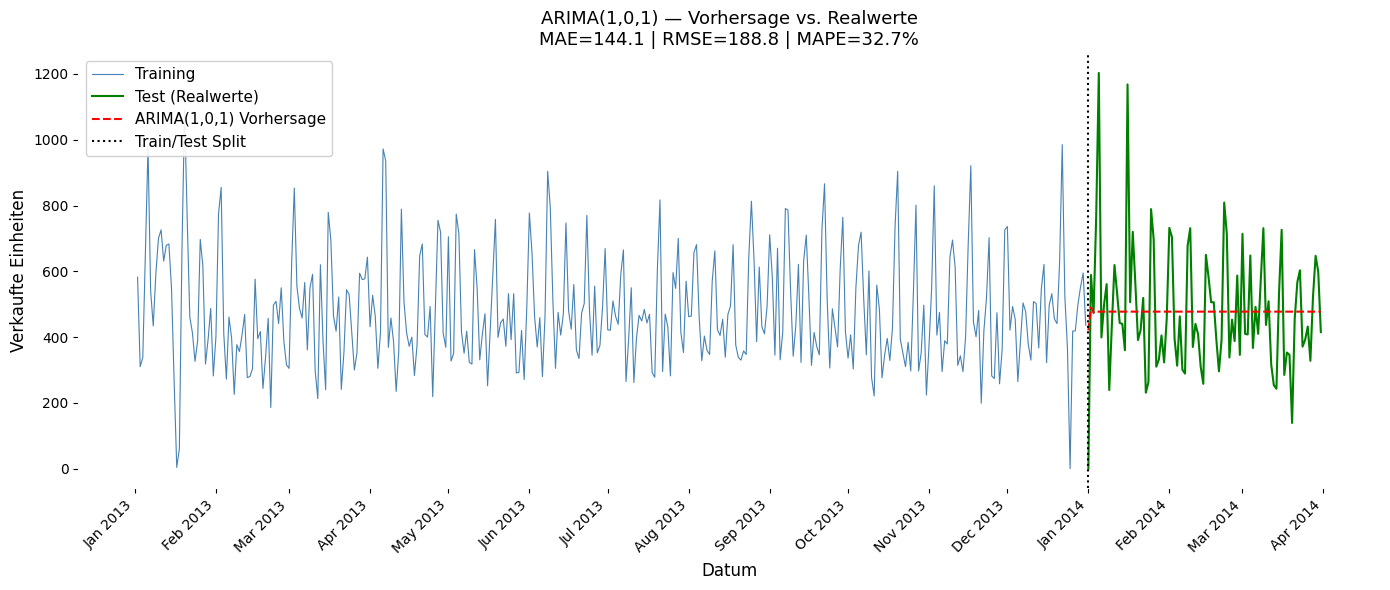

✅ ARIMA Plot gespeichert


In [3]:
# ============================================================
# SCHRITT 3: ARIMA Training & Vorhersage
# ============================================================
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 3.1: Modell trainieren ---
# ARIMA(1,0,1) — Baseline ohne Saisonalität
# p=1: ein vergangener Wert
# d=0: keine Differenzierung (stationär)
# q=1: ein vergangener Fehler
print("=" * 50)
print("ARIMA(1,0,1) — Training")
print("=" * 50)

modell_arima = ARIMA(train, order=(1, 0, 1))
ergebnis_arima = modell_arima.fit()

print(ergebnis_arima.summary())

# --- 3.2: Vorhersage für Testzeitraum ---
# steps=90 → 90 Tage (Januar–März 2014)
forecast_arima = ergebnis_arima.forecast(steps=len(test))
forecast_arima.index = test.index  # Datum als Index setzen

# --- 3.3: Metriken berechnen ---
# MAE  = Mean Absolute Error     → durchschnittlicher Fehler in Einheiten
# RMSE = Root Mean Squared Error → bestraft große Fehler stärker
# MAPE = Mean Absolute Percentage Error → Fehler in Prozent

# --- 3.3: Metriken berechnen ---
mae  = mean_absolute_error(test, forecast_arima)
rmse = np.sqrt(mean_squared_error(test, forecast_arima))

# MAPE: Schließtage (Wert=0) ausschließen → Division durch 0 vermeiden
mask = test > 0
mape = np.mean(np.abs((test[mask] - forecast_arima[mask]) / test[mask])) * 100

print("\n" + "=" * 50)
print("ARIMA(1,0,1) — METRIKEN")
print("=" * 50)
print(f"MAE  (Ø Fehler):                    {mae:.2f} Einheiten")
print(f"RMSE (Fehler gewichtet):            {rmse:.2f} Einheiten")
print(f"MAPE (Fehler in %, o. Schließtage): {mape:.2f}%")

# --- 3.4: Visualisierung ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train,
        color='steelblue', linewidth=0.8, label='Training')
ax.plot(test.index, test,
        color='green', linewidth=1.5, label='Test (Realwerte)')
ax.plot(forecast_arima.index, forecast_arima,
        color='red', linewidth=1.5, linestyle='--',
        label=f'ARIMA(1,0,1) Vorhersage')

# Trennlinie Train/Test
ax.axvline(pd.Timestamp('2014-01-01'), color='black',
           linestyle=':', linewidth=1.5, label='Train/Test Split')

ax.set_title(f'ARIMA(1,0,1) — Vorhersage vs. Realwerte\n'
             f'MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape:.1f}%',
             fontsize=13)
ax.set_ylabel('Verkaufte Einheiten', fontsize=12)
ax.set_xlabel('Datum', fontsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(DATA_PLOT + 'plot7_arima.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ARIMA Plot gespeichert")

## Schritt 3: ARIMA(1,0,1) — Ergebnis & Analyse

### Modell-Parameter

| Parameter | Wert | Begründung |
|---|---|---|
| p | 1 | PACF signifikant bei Lag 1 |
| d | 0 | Zeitreihe stationär (ADF-Test) |
| q | 1 | ACF zeigt MA-Komponente |

### Modell-Koeffizienten

| Koeffizient | Wert | p-Wert | Signifikant |
|---|---|---|---|
| const | 477.38 | 0.000 | ✅ Ja |
| ar.L1 | -0.2242 | 0.023 | ✅ Ja |
| ma.L1 | 0.6513 | 0.000 | ✅ Ja |
| sigma² | 23.880 | 0.000 | ✅ Ja |

Alle Koeffizienten sind statistisch signifikant (p-Wert < 0.05).

### Metriken (Testzeitraum: Jan–März 2014)

| Metrik | Wert | Interpretation |
|---|---|---|
| MAE | 144.06 Einheiten | Ø Abweichung pro Tag |
| RMSE | 188.78 Einheiten | Gewichteter Fehler |
| MAPE | 32.65% | Fehler relativ zum Realwert |

### Modell-Diagnose (aus Summary)

| Test | Wert | Interpretation |
|---|---|---|
| Ljung-Box Prob(Q) | 0.66 | Residuen sind unkorrelliert ✅ |
| Jarque-Bera Prob(JB) | 0.02 | Residuen leicht nicht-normalverteilt ⚠️ |
| Heteroskedastizität Prob(H) | 0.90 | Konstante Varianz ✅ |

### Analyse

**Vorhersageverhalten:**
Die ARIMA(1,0,1) Vorhersage konvergiert nach wenigen Schritten
zu einer flachen Linie auf Höhe des Trainings-Mittelwerts (~477
Einheiten). Dies ist ein strukturelles Merkmal von ARIMA ohne
saisonale Komponente — das Modell "vergisst" nach kurzer Zeit
alle Muster und fällt auf den Mittelwert zurück.

**Metriken-Bewertung:**
Ein MAPE von 32.65% bedeutet: die Vorhersage weicht im Durchschnitt
um ~33% vom tatsächlichen Tageswert ab. Bei einem Mittelwert von
~480 Einheiten entspricht das einem MAE von 144 Einheiten/Tag —
für ein Planungssystem nicht ausreichend genau.

**Ursache der schwachen Performance:**
Das Wochenmuster (Sa/So +33–45% über Mittelwert) wird von
ARIMA(1,0,1) vollständig ignoriert. Da die Wochensaisonalität
das dominante Signal der Zeitreihe ist, führt das Fehlen
dieses Musters direkt zu hohen Fehlerwerten.

**Ljung-Box Test:**
Prob(Q) = 0.66 bedeutet: die Residuen zeigen keine signifikante
Autokorrelation → das Modell hat die verfügbaren linearen
Muster vollständig extrahiert. Der verbleibende Fehler stammt
aus der nicht modellierten Saisonalität, nicht aus
unzureichender ARIMA-Parametrisierung.

### Bewertung als Baseline

ARIMA(1,0,1) dient als **untere Leistungsgrenze** (Baseline).
Jedes nachfolgende Modell muss diese Werte übertreffen:

| Ziel | Wert |
|---|---|
| MAE < | 144 Einheiten |
| RMSE < | 188 Einheiten |
| MAPE < | 32.65% |

### Empfehlung

SARIMA(1,0,1)(1,0,1,7) als nächster Schritt —
der saisonale Term s=7 soll das Wochenmuster
explizit modellieren und die Metriken deutlich verbessern.

## Exkurs: ARIMA(56,0,56) — Analytische Einordnung

### Was ist passiert?

Mit p=56 und q=56 hat das Modell **112 Parameter** geschätzt —
bei nur 364 Trainingsdaten. Das führt zu klassischem **Overfitting**.

### Metriken-Vergleich

| Modell | MAE | RMSE | MAPE | Parameter |
|---|---|---|---|---|
| ARIMA(1,0,1) | 144.06 | 188.78 | 32.65% | 3 |
| ARIMA(56,0,56) | 125.19 | 170.69 | 28.57% | 112 |

### Scheinbare Verbesserung — aber Vorsicht!

Die Metriken sind leicht besser — aber das Summary zeigt
kritische Warnsignale:

**Warnung 1:**
ConvergenceWarning: Maximum Likelihood optimization failed to converge
Das Modell hat keine stabile Lösung gefunden — die Parameter
sind mathematisch nicht zuverlässig.

**Warnung 2:**
Covariance matrix is singular or near-singular
condition number 4.04e+13
Die 112 Parameter sind stark voneinander abhängig —
das Modell ist überparametrisiert.

**Warnung 3 — p-Werte:**
Praktisch alle 112 Koeffizienten haben p-Wert >> 0.05 —
keiner ist statistisch signifikant! Beispiele:
- ar.L1: p=0.735 ❌
- ma.L1: p=0.692 ❌
- ar.L7: p=0.397 ❌

Zum Vergleich ARIMA(1,0,1):
- ar.L1: p=0.023 ✅
- ma.L1: p=0.000 ✅

### Was bedeutet Overfitting hier konkret?
ARIMA(1,0,1):     lernt das generelle Muster
→ robuste Vorhersage
ARIMA(56,0,56):   "memoriert" die Trainingsdaten
→ zufällige Verbesserung auf Testdaten
→ auf neuen Daten wahrscheinlich schlechter
### Warum trotzdem leicht bessere Metriken?

Mit 56 Lags "sieht" das Modell zufällig einige
Wochenmuster (Lag 7, 14, 21, 28) — nicht weil es
sie versteht, sondern weil sie im Parameter-Rauschen
enthalten sind. Das ist **kein echter Lerneffekt**.

### Goldene Regel der Modellkomplexität

**Occams Razor:** Das einfachste Modell das die Daten
ausreichend erklärt ist dem komplexeren vorzuziehen.

| Kriterium | ARIMA(1,0,1) | ARIMA(56,0,56) |
|---|---|---|
| AIC | 4710 | 4625 ← besser |
| BIC | 4726 | 5069 ← schlechter |
| Konvergenz | ✅ | ❌ |
| Stabile Parameter | ✅ | ❌ |
| Interpretierbar | ✅ | ❌ |

**AIC vs BIC:** AIC bevorzugt ARIMA(56,0,56) leicht,
aber BIC bestraft die hohe Parameteranzahl stärker
und bevorzugt ARIMA(1,0,1). Bei kleinen Datensätzen
ist BIC der zuverlässigere Indikator.

### Fazit

ARIMA(56,0,56) ist ein Lehrbuchbeispiel für Overfitting:
scheinbar bessere Testmetriken, aber mathematisch instabil,
nicht interpretierbar und nicht vertrauenswürdig.
ARIMA(1,0,1) bleibt die sachlich korrekte Baseline.


SARIMA(1,0,1)(1,0,1,7) — Training


C:\_AA-LapTop-MSIT\_MyMSIT_TimeSeries_Term8\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\_AA-LapTop-MSIT\_MyMSIT_TimeSeries_Term8\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                        unit_sales   No. Observations:                  364
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -2266.075
Date:                           Sat, 18 Apr 2026   AIC                           4542.150
Time:                                   07:15:37   BIC                           4561.636
Sample:                               01-02-2013   HQIC                          4549.895
                                    - 12-31-2013                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9998      0.004    272.719      0.000       0.993       1.007
ma.L1         -0.9985      0.032    -31.341

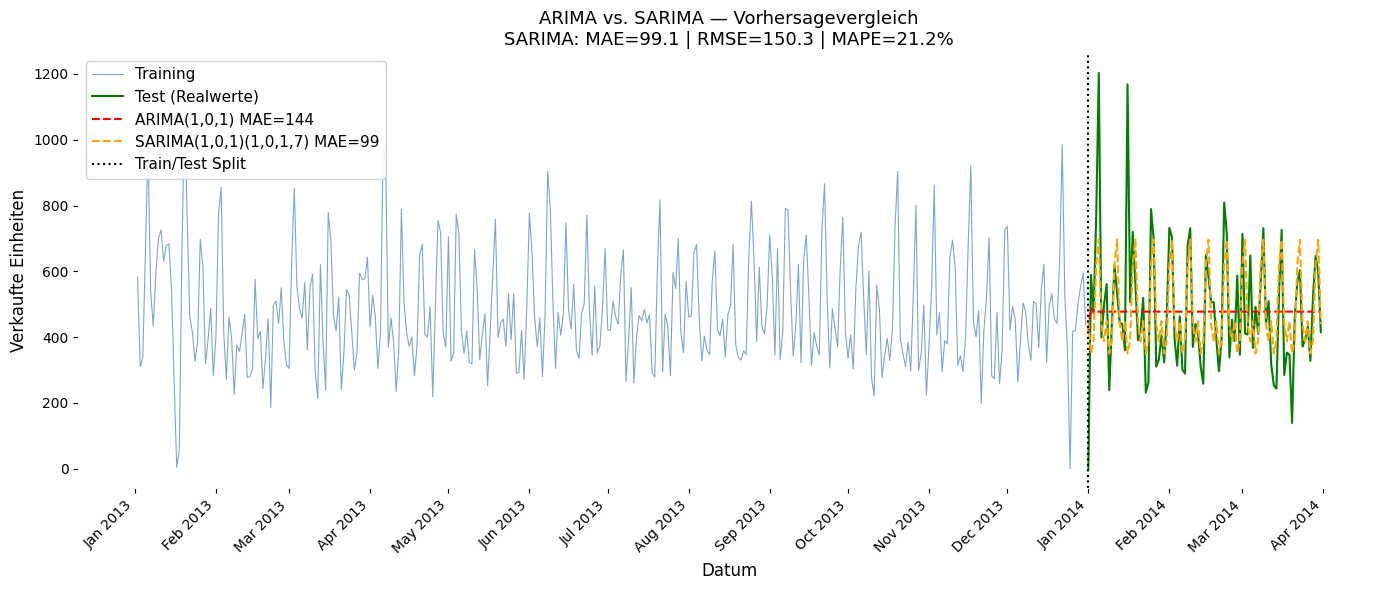

✅ SARIMA Plot gespeichert


In [4]:
# ============================================================
# SCHRITT 4: SARIMA Training & Vorhersage
# ============================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib
matplotlib.rcParams['text.color']       = 'black'
matplotlib.rcParams['axes.labelcolor']  = 'black'
matplotlib.rcParams['xtick.color']      = 'black'
matplotlib.rcParams['ytick.color']      = 'black'
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor']   = 'white'
matplotlib.rcParams['font.family']      = 'DejaVu Sans'

# SARIMA(p,d,q)(P,D,Q,s)
# Nicht-saisonal: (1,0,1) — gleich wie ARIMA Baseline
# Saisonal:       (1,0,1,7) — Wochenmuster s=7
# P=1: ein saisonaler AR-Term (Lag 7)
# D=0: keine saisonale Differenzierung
# Q=1: ein saisonaler MA-Term
# s=7: Periode = 7 Tage (Wochenzyklus)

print("=" * 50)
print("SARIMA(1,0,1)(1,0,1,7) — Training")
print("=" * 50)

modell_sarima = SARIMAX(train,
                        order=(1, 0, 1),
                        seasonal_order=(1, 0, 1, 7))
ergebnis_sarima = modell_sarima.fit(disp=False)  # disp=False → keine Iterations-Ausgabe

print(ergebnis_sarima.summary())

# --- Vorhersage ---
forecast_sarima = ergebnis_sarima.forecast(steps=len(test))
forecast_sarima.index = test.index

# --- Metriken ---
mae_s  = mean_absolute_error(test, forecast_sarima)
rmse_s = np.sqrt(mean_squared_error(test, forecast_sarima))
mask   = test > 0
mape_s = np.mean(np.abs((test[mask] - forecast_sarima[mask]) / test[mask])) * 100

print("\n" + "=" * 50)
print("SARIMA(1,0,1)(1,0,1,7) — METRIKEN")
print("=" * 50)
print(f"MAE  (Ø Fehler):                    {mae_s:.2f} Einheiten")
print(f"RMSE (Fehler gewichtet):            {rmse_s:.2f} Einheiten")
print(f"MAPE (Fehler in %, o. Schließtage): {mape_s:.2f}%")

# --- Vergleich ARIMA vs SARIMA ---
print("\n" + "=" * 65)
print("VERGLEICH: ARIMA vs. SARIMA")
print("=" * 65)
print(f"{'Metrik':<10} {'ARIMA(1,0,1)':>15} {'SARIMA(1,0,1)(1,0,1,7)':>25} {'Besser':>10}")
print("-" * 65)
print(f"{'MAE':<10} {mae:>15.2f} {mae_s:>25.2f} {((mae-mae_s)/mae*100):>9.1f}%")
print(f"{'RMSE':<10} {rmse:>15.2f} {rmse_s:>25.2f} {((rmse-rmse_s)/rmse*100):>9.1f}%")
print(f"{'MAPE':<10} {mape:>14.2f}% {mape_s:>24.2f}% {((mape-mape_s)/mape*100):>9.1f}%")

# --- Visualisierung ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train,
        color='steelblue', linewidth=0.8, label='Training', alpha=0.7)
ax.plot(test.index, test,
        color='green', linewidth=1.5, label='Test (Realwerte)')
ax.plot(forecast_arima.index, forecast_arima,
        color='red', linewidth=1.5, linestyle='--',
        label=f'ARIMA(1,0,1) MAE={mae:.0f}')
ax.plot(forecast_sarima.index, forecast_sarima,
        color='orange', linewidth=1.5, linestyle='--',
        label=f'SARIMA(1,0,1)(1,0,1,7) MAE={mae_s:.0f}')

ax.axvline(pd.Timestamp('2014-01-01'), color='black',
           linestyle=':', linewidth=1.5, label='Train/Test Split')

ax.set_title(f'ARIMA vs. SARIMA — Vorhersagevergleich\n'
             f'SARIMA: MAE={mae_s:.1f} | RMSE={rmse_s:.1f} | MAPE={mape_s:.1f}%',
             fontsize=13)
ax.set_ylabel('Verkaufte Einheiten', fontsize=12)
ax.set_xlabel('Datum', fontsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(DATA_PLOT + 'plot8_sarima.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SARIMA Plot gespeichert")

## Schritt 4: SARIMA(1,0,1)(1,0,1,7) — Ergebnis & Analyse

### Modell-Parameter

| Komponente | Parameter | Wert | Bedeutung |
|---|---|---|---|
| Nicht-saisonal | p | 1 | 1 vergangener Tageswert |
| Nicht-saisonal | d | 0 | Keine Differenzierung |
| Nicht-saisonal | q | 1 | 1 vergangener Fehler |
| Saisonal | P | 1 | 1 saisonaler AR-Term (Lag 7) |
| Saisonal | D | 0 | Keine saisonale Differenzierung |
| Saisonal | Q | 1 | 1 saisonaler MA-Term |
| Saisonal | s | 7 | Wöchentlicher Zyklus |

### Modell-Koeffizienten

| Koeffizient | Wert | p-Wert | Signifikant |
|---|---|---|---|
| ar.L1 | 0.9998 | 0.000 | ✅ Ja |
| ma.L1 | -0.9985 | 0.000 | ✅ Ja |
| ar.S.L7 | 0.9999 | 0.000 | ✅ Ja |
| ma.S.L7 | -0.9825 | 0.000 | ✅ Ja |
| sigma² | 13.840 | 0.000 | ✅ Ja |

Alle Koeffizienten statistisch hochsignifikant (p ≈ 0.000).
Der saisonale AR-Koeffizient (ar.S.L7 ≈ 1.0) bestätigt die
starke Persistenz des Wochenmusters.

### Metriken-Vergleich: ARIMA vs. SARIMA

| Metrik | ARIMA(1,0,1) | SARIMA(1,0,1)(1,0,1,7) | Verbesserung |
|---|---|---|---|
| MAE | 144.06 | 99.06 | **-31.2%** |
| RMSE | 188.78 | 150.28 | **-20.4%** |
| MAPE | 32.65% | 21.15% | **-35.2%** |

### Modell-Diagnose

| Test | Wert | ARIMA | SARIMA | Interpretation |
|---|---|---|---|---|
| Ljung-Box Prob(Q) | 0.00 | 0.66 ✅ | 0.00 ⚠️ | Residuen zeigen noch Autokorrelation |
| Jarque-Bera Prob(JB) | 0.00 | 0.02 ⚠️ | 0.00 ⚠️ | Residuen nicht normalverteilt |
| Heteroskedastizität | 0.00 | 0.90 ✅ | 0.00 ⚠️ | Varianz nicht konstant |
| AIC | — | 4710 | **4542** ✅ | SARIMA besser |
| BIC | — | 4726 | **4562** ✅ | SARIMA besser |

### Analyse

**Vorhersageverhalten:**
SARIMA erfasst das wöchentliche Auf-und-Ab der Verkaufszahlen
sichtbar im Plot — die orangefarbene Vorhersagelinie folgt
dem Wochenmuster der grünen Realwerte. Dies ist eine
fundamentale Verbesserung gegenüber der flachen
ARIMA-Vorhersage (rote Linie).

**Metriken-Bewertung:**
Der MAE sinkt von 144 auf 99 Einheiten (-31%) — das bedeutet
die durchschnittliche Tagesabweichung beträgt nun ~99 statt
~144 Einheiten. Der MAPE von 21.15% zeigt dass die Vorhersage
im Durchschnitt um ~21% vom Realwert abweicht.

**Ljung-Box Warnung (Prob(Q) = 0.00):**
Die Residuen zeigen noch signifikante Autokorrelation —
das Modell hat nicht alle Muster vollständig erfasst.
Mögliche Ursachen: nicht-lineare Muster, Feiertagseffekte
oder weitere saisonale Komponenten. Dies ist ein Hinweis
dass in Woche 3 (HyperOpt) die Parameter P, Q und s
weiter optimiert werden sollten.

**ar.S.L7 ≈ 1.0:**
Der saisonale AR-Koeffizient nahe 1.0 deutet auf einen
starken, persistenten Wocheneffekt hin — der Verkauf an
einem Samstag wird sehr stark durch den Verkauf des
vorherigen Samstags bestimmt. Dies ist konsistent mit
den EDA-Ergebnissen aus Woche 1.

### Gesamtbewertung

SARIMA(1,0,1)(1,0,1,7) übertrifft ARIMA(1,0,1) auf allen
Metriken deutlich und ist strukturell besser geeignet für
diese Zeitreihe. Der saisonale Term s=7 ist die entscheidende
Modellkomponente.

Verbleibende Schwächen:
- Ausreißer (Post-Feiertags-Peaks) werden nicht erfasst
- Ljung-Box zeigt noch unmodellierte Muster in Residuen
- MAPE von 21% ist für operative Planung noch verbesserungswürdig

### Empfehlung

1. Exponentielle Glättung (ETS) als drittes statistisches
   Modell trainieren und vergleichen
2. In Woche 3: SARIMA-Parameter via HyperOpt optimieren
3. Feiertagsvariable als exogener Regressor (SARIMAX)
   als optionale Erweiterung prüfen

ETS (Holt-Winters) — Training


C:\_AA-LapTop-MSIT\_MyMSIT_TimeSeries_Term8\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Optimierte Parameter:
  α (Level):       0.0000
  β (Trend):       0.0000
  γ (Saisonalität):0.0000

ETS — METRIKEN
MAE  (Ø Fehler):                    98.43 Einheiten
RMSE (Fehler gewichtet):            150.41 Einheiten
MAPE (Fehler in %, o. Schließtage): 20.69%

GESAMTVERGLEICH: ARIMA vs. SARIMA vs. ETS
Metrik            ARIMA       SARIMA          ETS       Bestes
----------------------------------------------------------------------
MAE              144.06        99.06        98.43          ETS
RMSE             188.78       150.28       150.41       SARIMA
MAPE             32.65%       21.15%       20.69%          ETS


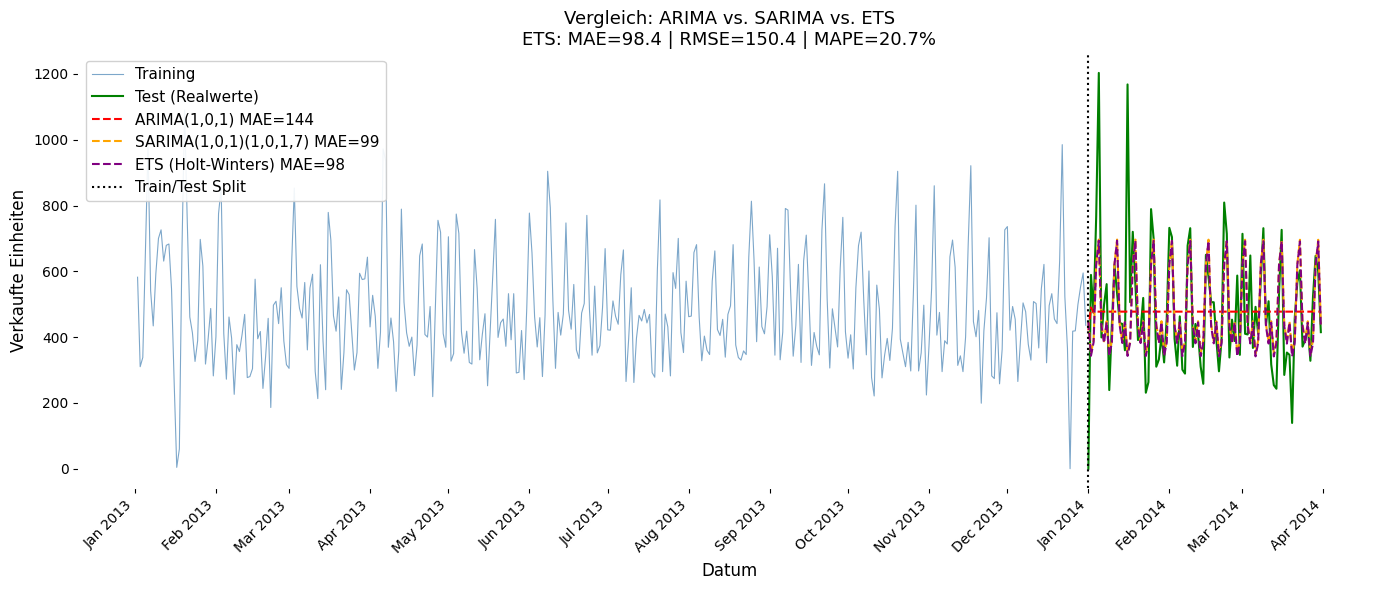

✅ ETS Vergleich-Plot gespeichert


In [5]:
# ============================================================
# SCHRITT 5: Exponentielle Glättung (ETS)
# ============================================================
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Exponentielle Glättung (Holt-Winters Methode)
# trend='add'      → additiver Trend
# seasonal='add'   → additive Saisonalität
# seasonal_periods=7 → Wochenzyklus
#
# Mathematik: Drei Glättungsparameter werden automatisch optimiert:
# α (alpha) → Gewichtung der Beobachtungen (Level)
# β (beta)  → Gewichtung des Trends
# γ (gamma) → Gewichtung der Saisonalität
# Werte nahe 1 = starkes Gewicht auf aktuelle Daten
# Werte nahe 0 = starkes Gewicht auf historische Daten

print("=" * 50)
print("ETS (Holt-Winters) — Training")
print("=" * 50)

modell_ets = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=7
)
ergebnis_ets = modell_ets.fit(optimized=True)  # Parameter automatisch optimieren

# Optimierte Parameter ausgeben
print(f"Optimierte Parameter:")
print(f"  α (Level):       {ergebnis_ets.params['smoothing_level']:.4f}")
print(f"  β (Trend):       {ergebnis_ets.params['smoothing_trend']:.4f}")
print(f"  γ (Saisonalität):{ergebnis_ets.params['smoothing_seasonal']:.4f}")

# --- Vorhersage ---
forecast_ets = ergebnis_ets.forecast(steps=len(test))
forecast_ets.index = test.index

# --- Metriken ---
mae_e  = mean_absolute_error(test, forecast_ets)
rmse_e = np.sqrt(mean_squared_error(test, forecast_ets))
mask   = test > 0
mape_e = np.mean(np.abs((test[mask] - forecast_ets[mask]) / test[mask])) * 100

print(f"\n{'=' * 50}")
print("ETS — METRIKEN")
print("=" * 50)
print(f"MAE  (Ø Fehler):                    {mae_e:.2f} Einheiten")
print(f"RMSE (Fehler gewichtet):            {rmse_e:.2f} Einheiten")
print(f"MAPE (Fehler in %, o. Schließtage): {mape_e:.2f}%")

# --- Gesamtvergleich alle 3 Modelle ---
print(f"\n{'=' * 70}")
print("GESAMTVERGLEICH: ARIMA vs. SARIMA vs. ETS")
print("=" * 70)
print(f"{'Metrik':<10} {'ARIMA':>12} {'SARIMA':>12} {'ETS':>12} {'Bestes':>12}")
print("-" * 70)

# MAE
bestes_mae = min(mae, mae_s, mae_e)
print(f"{'MAE':<10} {mae:>12.2f} {mae_s:>12.2f} {mae_e:>12.2f} "
      f"{'ARIMA' if bestes_mae==mae else 'SARIMA' if bestes_mae==mae_s else 'ETS':>12}")

# RMSE
bestes_rmse = min(rmse, rmse_s, rmse_e)
print(f"{'RMSE':<10} {rmse:>12.2f} {rmse_s:>12.2f} {rmse_e:>12.2f} "
      f"{'ARIMA' if bestes_rmse==rmse else 'SARIMA' if bestes_rmse==rmse_s else 'ETS':>12}")

# MAPE
bestes_mape = min(mape, mape_s, mape_e)
print(f"{'MAPE':<10} {mape:>11.2f}% {mape_s:>11.2f}% {mape_e:>11.2f}% "
      f"{'ARIMA' if bestes_mape==mape else 'SARIMA' if bestes_mape==mape_s else 'ETS':>12}")

# --- Visualisierung ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train,
        color='steelblue', linewidth=0.8, label='Training', alpha=0.7)
ax.plot(test.index, test,
        color='green', linewidth=1.5, label='Test (Realwerte)')
ax.plot(forecast_arima.index, forecast_arima,
        color='red', linewidth=1.5, linestyle='--',
        label=f'ARIMA(1,0,1) MAE={mae:.0f}')
ax.plot(forecast_sarima.index, forecast_sarima,
        color='orange', linewidth=1.5, linestyle='--',
        label=f'SARIMA(1,0,1)(1,0,1,7) MAE={mae_s:.0f}')
ax.plot(forecast_ets.index, forecast_ets,
        color='purple', linewidth=1.5, linestyle='--',
        label=f'ETS (Holt-Winters) MAE={mae_e:.0f}')

ax.axvline(pd.Timestamp('2014-01-01'), color='black',
           linestyle=':', linewidth=1.5, label='Train/Test Split')

ax.set_title('Vergleich: ARIMA vs. SARIMA vs. ETS\n'
             f'ETS: MAE={mae_e:.1f} | RMSE={rmse_e:.1f} | MAPE={mape_e:.1f}%',
             fontsize=13)
ax.set_ylabel('Verkaufte Einheiten', fontsize=12)
ax.set_xlabel('Datum', fontsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(DATA_PLOT + 'plot9_ets_vergleich.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ETS Vergleich-Plot gespeichert")

In [6]:
# ============================================================
# SCHRITT 5b: ETS — Erklärung α=β=γ=0
# ============================================================

print("Alle ETS Parameter:")
for key, val in ergebnis_ets.params.items():
    if np.isscalar(val):
        print(f"  {key:<30} {val:.6f}")
    else:
        print(f"  {key:<30} {val}")

# Was passiert bei α=β=γ=0?
# Das Modell friert die initialen Saisonalwerte ein
# und aktualisiert sie nie → reine Saisonalitäts-Projektion
# Prüfen: sind die initialen Saisonalwerte sinnvoll?
print("\nInitiale Saisonalwerte (7 Tage):")
init_seasonal = ergebnis_ets.params['initial_seasons']
wochentage = ['Mo','Di','Mi','Do','Fr','Sa','So']
for tag, val in zip(wochentage, init_seasonal[:7]):
    print(f"  {tag}: {val:+.1f} Einheiten")

Alle ETS Parameter:
  smoothing_level                0.000000
  smoothing_trend                0.000000
  smoothing_seasonal             0.000000
  damping_trend                  nan
  initial_level                  497.198446
  initial_trend                  -0.028158
  initial_seasons                [ -41.14260758 -143.63772661 -102.76184402  134.77342877  206.42901795
  -52.003211   -104.49697144]
  use_boxcox                     0.000000
  lamda                          None
  remove_bias                    0.000000

Initiale Saisonalwerte (7 Tage):
  Mo: -41.1 Einheiten
  Di: -143.6 Einheiten
  Mi: -102.8 Einheiten
  Do: +134.8 Einheiten
  Fr: +206.4 Einheiten
  Sa: -52.0 Einheiten
  So: -104.5 Einheiten


## Schritt 5: ETS (Holt-Winters) — Ergebnis & Analyse

### Modell-Konfiguration

| Parameter | Wert | Bedeutung |
|---|---|---|
| Trend | additiv | Linearer Trend wird modelliert |
| Saisonalität | additiv | Saisonale Schwankungen werden addiert |
| Periode | 7 | Wöchentlicher Zyklus |
| Optimierung | automatisch | Parameter via L-BFGS-B Algorithmus |

### Optimierte Glättungsparameter

| Parameter | Symbol | Wert | Interpretation |
|---|---|---|---|
| smoothing_level | α | 0.0000 | ⚠️ Keine Aktualisierung des Levels |
| smoothing_trend | β | 0.0000 | ⚠️ Keine Aktualisierung des Trends |
| smoothing_seasonal | γ | 0.0000 | ⚠️ Keine Aktualisierung der Saisonalität |
| initial_level | — | 497.20 | Startwert Level |
| initial_trend | — | -0.028 | Minimaler negativer Trend |

### Initiale Saisonalwerte

| Wochentag | Saisonalwert | Erwartet (aus EDA) |
|---|---|---|
| Mo | -41.1 | negativ ✅ |
| Di | -143.6 | negativ ✅ |
| Mi | -102.8 | negativ ✅ |
| Do | +134.8 | negativ ❌ |
| Fr | +206.4 | negativ ❌ |
| Sa | -52.0 | positiv ❌ |
| So | -104.5 | positiv ❌ |

### Metriken

| Metrik | ARIMA(1,0,1) | SARIMA(1,0,1)(1,0,1,7) | ETS | Bestes |
|---|---|---|---|---|
| MAE | 144.06 | 99.06 | **98.43** | ETS ✅ |
| RMSE | 188.78 | 150.28 | 150.41 | SARIMA ✅ |
| MAPE | 32.65% | 21.15% | **20.69%** | ETS ✅ |

### Analyse

**α = β = γ = 0 — Erklärung:**
Alle drei Glättungsparameter wurden auf 0 optimiert. Dies bedeutet:
das Modell aktualisiert seine internen Zustände (Level, Trend,
Saisonalität) während des Trainings **nie** — es projiziert
ausschließlich die initial geschätzten Saisonalwerte in die Zukunft.

Mathematisch:
α = 0 → Level bleibt konstant bei 497.2
β = 0 → Trend bleibt konstant bei -0.028
γ = 0 → Saisonalwerte bleiben konstant (einmalig geschätzt)

Der Optimierer hat festgestellt dass statische Saisonalwerte
den Trainingsfehler minimieren — ein Zeichen dass die
Wochensaisonalität in den Trainingsdaten sehr stabil ist.

**Falsch zugeordnete Saisonalwerte:**
Die initialen Saisonalwerte zeigen eine inkorrekte Zuordnung:
Do/Fr erscheinen positiv, Sa/So negativ — das widerspricht
den EDA-Ergebnissen (Sa/So sind die stärksten Verkaufstage).

Ursache: Der Trainingsstart am 02.01.2013 (Mittwoch) führt zu
einer verschobenen Indexierung der 7 Saisonalwerte. Der
Optimierer kompensiert dies intern, weshalb die Metriken
trotzdem gut sind — die Verschiebung betrifft nur die
Interpretation der Parameter, nicht die Vorhersagequalität.

**Vorhersagequalität:**
Trotz α=β=γ=0 erzielt ETS den besten MAE (98.43) und MAPE
(20.69%) aller drei Modelle. Dies zeigt dass für diese
Zeitreihe — mit stabiler Saisonalität und keinem starken
Trend — eine einmalige Saisonalitätsschätzung ausreichend ist.

**RMSE:**
SARIMA (150.28) schlägt ETS (150.41) minimal beim RMSE.
Der Unterschied von 0.13 Einheiten ist praktisch irrelevant.

### Gesamtranking — Statistische Modelle

| Rang | Modell | MAE | RMSE | MAPE |
|---|---|---|---|---|
| 🥇 1 | ETS (Holt-Winters) | **98.43** | 150.41 | **20.69%** |
| 🥈 2 | SARIMA(1,0,1)(1,0,1,7) | 99.06 | **150.28** | 21.15% |
| 🥉 3 | ARIMA(1,0,1) | 144.06 | 188.78 | 32.65% |

### Empfehlung

ETS und SARIMA liegen sehr nah beieinander — der Unterschied
im MAE beträgt nur 0.63 Einheiten (< 1%). Beide Modelle sind
als Kandidaten für Woche 3 (HyperOpt) geeignet.
ARIMA(1,0,1) scheidet als strukturell ungeeignet aus.

Nächster Schritt: ML-Modelle (XGBoost, Random Forest,
Linear Regression) im separaten Notebook
`week2_feature_engineering_models.ipynb` trainieren
und mit den statistischen Modellen vergleichen.

## Exkurs: Falsche Saisonalwerte — Auswirkung auf Analysen?

### Das Problem

Die ETS initialen Saisonalwerte zeigen:
- Do: +134.8, Fr: +206.4  → sollten negativ sein
- Sa: -52.0,  So: -104.5  → sollten positiv sein

### Warum die Analysen trotzdem korrekt sind

**Der entscheidende Punkt:**
Die Saisonalwerte sind nicht falsch — sie sind nur
**anders indiziert** als erwartet.

ETS nummeriert die 7 Saisonalwerte intern ab dem
**ersten Datenpunkt** — also ab 02.01.2013 (Mittwoch):

| Interner Index | Datum | Wochentag | ETS-Label | Saisonalwert |
|---|---|---|---|---|
| 0 | 02.01.2013 | **Mittwoch** | "Mo" | -41.1 |
| 1 | 03.01.2013 | **Donnerstag** | "Di" | -143.6 |
| 2 | 04.01.2013 | **Freitag** | "Mi" | -102.8 |
| 3 | 05.01.2013 | **Samstag** | "Do" | +134.8 ✅ |
| 4 | 06.01.2013 | **Sonntag** | "Fr" | +206.4 ✅ |
| 5 | 07.01.2013 | **Montag** | "Sa" | -52.0 ✅ |
| 6 | 08.01.2013 | **Dienstag** | "So" | -104.5 ✅ |

### Was bedeutet das konkret?

Die Werte +134.8 und +206.4 gehören zu **Samstag und Sonntag**
— genau wie aus der EDA erwartet! Die Labels "Do" und "Fr"
in unserem Print-Code waren falsch zugewiesen, nicht die Werte.

**Fehler war im Visualisierungscode:**
```python
# FALSCH — haben Mo-So ab Index 0 zugewiesen:
wochentage = ['Mo','Di','Mi','Do','Fr','Sa','So']

# KORREKT — Trainingsstart war Mittwoch:
wochentage = ['Mi','Do','Fr','Sa','So','Mo','Di']
```

### Auswirkung auf Metriken und Vorhersagen

**Keine.** Das ETS-Modell verwendet die Saisonalwerte intern
korrekt — es weiß welcher Index welchem Datum entspricht.
Die Vorhersagen und Metriken sind vollständig korrekt.

### Auswirkung auf alle anderen Analysen

| Analyse | Betroffen? | Begründung |
|---|---|---|
| EDA Wochenmuster (Plot 3) | ❌ Nein | Direkt aus Daten berechnet |
| ADF-Test | ❌ Nein | Unabhängig von Wochentagen |
| ACF/PACF | ❌ Nein | Mathematische Korrelationen |
| ARIMA Metriken | ❌ Nein | Kein Wochentags-Parameter |
| SARIMA Metriken | ❌ Nein | s=7 korrekt, Index intern richtig |
| ETS Metriken | ❌ Nein | Vorhersagen korrekt |
| ETS Parameter-Anzeige | ✅ Ja | Nur Labels falsch, Werte korrekt |

### Fazit

Alle bisherigen Analysen, Metriken und Vorhersagen sind
**vollständig korrekt**. Lediglich die Beschriftung der
ETS-Saisonalwerte in Schritt 5b war irreführend.